## Aim 

In this notebook, some road characteristics per ward are created. This is done by reading in the entire Bangalore road network and then clipping it per ward. 

## Reading in the Python libraries

In [1]:
from pathlib import Path

import geopandas as gpd
import osmnx as ox
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

## Loading the data

In [8]:
BASE_DIR = Path.cwd().parent
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"
## LOGS_DIR = BASE_DIR / "logs"

path_graphml = DATA_DIR / "graphml_chennai" / "chennai_graphml.graphml"

# WARDS_GPKG_DIR = DATA_DIR / "gpkgs"
# WARDS_G_DIR =  DATA_DIR / "g_files"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [3]:
## Detailed wards
df_inpath = PROCESSED_DIR / "chennai_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\chennai_fix_mapshaper.shp


In [4]:
## Detailed wards
df_inpath = PROCESSED_DIR / "chennai_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\chennai_fix_mapshaper.shp


In [5]:
df = gpd.read_file(df_inpath)
df.head()

,Name,zone_id,zone_name,geometry
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584..."
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ..."
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ..."
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13...."
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318..."


In [6]:
print(f'There are {df.shape[0]} wards in the dataset')

There are 200 wards in the dataset


Reading in the graph data (still in EPSG 4326):

In [9]:
G = ox.io.load_graphml(path_graphml)

In [10]:
G.graph["crs"]

'epsg:4326'

In [11]:
df.crs.to_epsg()

4326

The two coordinate systems need to be the same.

## Loop with road characteristics for each ward

Initialise the dataframe:

In [25]:
results = pd.DataFrame(columns=['Name', 'zone_id', 'zone_name', 'street_length', 'street_density', 'area'])
results

,Name,zone_id,zone_name,street_length,street_density,area


In [26]:
df.crs.to_epsg()

4326

In [27]:
## for ward in tqdm(range(0,5), desc="Processing wards"):
for ward in tqdm(range(0,len(df)), desc = "Processing wards"):

    # print(f'Processing the {ward} ward.')

    Name = df['Name'].iloc[ward]
    zone_id = df['zone_id'].iloc[ward]
    zone_name = df['zone_name'].iloc[ward]

    df_ward = df.iloc[[ward]]

    ## ward_geometry = df.iloc[ward,:].geometry
    ward_geometry = df_ward.geometry.iloc[0]
    
    G_clipped = ox.truncate.truncate_graph_polygon(G, ward_geometry)

    G_clipped_proj = ox.projection.project_graph(G_clipped)

    ward_area = ox.projection.project_gdf(df_ward).union_all().area
    ## print(ward_area)

    stats_area = ox.basic_stats(G_clipped_proj, area=ward_area)

    

    results.loc[ward] = [
        Name,
        zone_id,
        zone_name,
        stats_area['street_length_total'],
        stats_area['street_density_km'],
        ward_area
    ]

Processing wards: 100%|██████████████████████████████████████████████████████████████| 200/200 [13:44<00:00,  4.12s/it]


In [28]:
results

,Name,zone_id,zone_name,street_length,street_density,area
0,168,13,Adyar,75169.504436,21098.044012,3.562866e+06
1,169,13,Adyar,73317.480822,19458.220252,3.767944e+06
2,170,13,Adyar,49375.041995,18280.088566,2.701029e+06
3,171,13,Adyar,54634.286214,16309.207438,3.349904e+06
4,174,13,Adyar,52844.744254,15261.443669,3.462631e+06
...,...,...,...,...,...,...
195,110,9,Teynampet,45308.674095,22062.191786,2.053680e+06
196,161,12,Alandur,13211.312827,16730.798360,7.896403e+05
197,160,12,Alandur,10652.094770,15903.379548,6.698007e+05
198,195,15,Sholinganallur,61005.764641,24514.119499,2.488597e+06


In [29]:
## Save this:
results_path = PROCESSED_DIR / "results_chennai_all_roads.csv"

results.to_csv(results_path)

In [30]:
print(f'The minimum density is {results["street_density"].min()}. metres per square kilometer')
print(f'The maximum density is {results["street_density"].max()}. metres per square kilometer')

The minimum density is 4316.475561270958. metres per square kilometer
The maximum density is 31796.66127820001. metres per square kilometer


The ten wards with the highest density:

In [31]:
top10_highest = (
    results
    .sort_values(by='street_density', ascending=False)
    .head(10)
)
top10_highest

,Name,zone_id,zone_name,street_length,street_density,area
150,47,4,Tondiarpet,19809.441534,31796.661278,6.230038e+05
32,116,9,Teynampet,21519.020570,31650.757476,6.798896e+05
143,41,4,Tondiarpet,26187.039346,29354.950111,8.920826e+05
155,36,4,Tondiarpet,40351.831639,29334.840002,1.375560e+06
91,67,6,Thiru-Vi-Ka. Nagar,25547.742602,28403.216859,8.994665e+05
136,138,10,Kodambakkam,35661.472082,28214.481224,1.263942e+06
190,91,7,Ambattur,34162.734936,28091.832121,1.216109e+06
9,177,13,Adyar,76743.756259,27633.699864,2.777180e+06
105,148,11,Valasaravakkam,24052.968799,27248.436648,8.827284e+05
188,65,6,Thiru-Vi-Ka. Nagar,50609.806956,26891.432916,1.882005e+06


The wards with the lowest density:

In [33]:
top10_lowest = (
    results
    .sort_values(by='street_density', ascending=True)
    .head(10)
)
top10_lowest

,Name,zone_id,zone_name,street_length,street_density,area
85,159,12,Alandur,14533.825062,4316.475561,3.367058e+06
60,15,2,Manali,43031.921731,4943.585084,8.704598e+06
61,16,2,Manali,77085.516405,7688.229604,1.002643e+07
62,17,2,Manali,54069.019225,8100.525685,6.674754e+06
25,189,14,Perungudi,86590.478808,8491.157675,1.019772e+07
63,18,2,Manali,78971.462941,9782.509954,8.072720e+06
160,3,1,Thiruvottyur,31216.054529,9874.229171,3.161366e+06
159,2,1,Thiruvottyur,29008.685231,9948.230755,2.915964e+06
169,22,2,Manali,23375.384194,10856.802630,2.153063e+06
55,96,8,Anna Nagar,32192.084543,11702.969803,2.750762e+06


Plot the ward with the highest and lowest street density, First merge this with the wards dataframe:

In [34]:
df_merged = df.merge(results, on = 'Name')
df_merged

,Name,zone_id_x,zone_name_x,geometry,zone_id_y,zone_name_y,street_length,street_density,area
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584...",13,Adyar,75169.504436,21098.044012,3.562866e+06
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ...",13,Adyar,73317.480822,19458.220252,3.767944e+06
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ...",13,Adyar,49375.041995,18280.088566,2.701029e+06
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13....",13,Adyar,54634.286214,16309.207438,3.349904e+06
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318...",13,Adyar,52844.744254,15261.443669,3.462631e+06
...,...,...,...,...,...,...,...,...,...
195,110,9,Teynampet,"POLYGON ((80.23114 13.05407, 80.23115 13.05415...",9,Teynampet,45308.674095,22062.191786,2.053680e+06
196,161,12,Alandur,"POLYGON ((80.20783 13.00072, 80.20781 13.00064...",12,Alandur,13211.312827,16730.798360,7.896403e+05
197,160,12,Alandur,"MULTIPOLYGON (((80.20702 12.99931, 80.20702 12...",12,Alandur,10652.094770,15903.379548,6.698007e+05
198,195,15,Sholinganallur,"POLYGON ((80.24569 12.93725, 80.24554 12.93576...",15,Sholinganallur,61005.764641,24514.119499,2.488597e+06


In [35]:
df_merged = df_merged[['Name', 'zone_id_x', 'zone_name_x', 'geometry', 'street_length', 'street_density', 'area']]
df_merged

,Name,zone_id_x,zone_name_x,geometry,street_length,street_density,area
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584...",75169.504436,21098.044012,3.562866e+06
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ...",73317.480822,19458.220252,3.767944e+06
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ...",49375.041995,18280.088566,2.701029e+06
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13....",54634.286214,16309.207438,3.349904e+06
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318...",52844.744254,15261.443669,3.462631e+06
...,...,...,...,...,...,...,...
195,110,9,Teynampet,"POLYGON ((80.23114 13.05407, 80.23115 13.05415...",45308.674095,22062.191786,2.053680e+06
196,161,12,Alandur,"POLYGON ((80.20783 13.00072, 80.20781 13.00064...",13211.312827,16730.798360,7.896403e+05
197,160,12,Alandur,"MULTIPOLYGON (((80.20702 12.99931, 80.20702 12...",10652.094770,15903.379548,6.698007e+05
198,195,15,Sholinganallur,"POLYGON ((80.24569 12.93725, 80.24554 12.93576...",61005.764641,24514.119499,2.488597e+06


In [36]:
# Rename the columns
df_merged = df_merged.rename(columns={
    'zone_id_x': 'zone_id',
    'zone_name_x': 'zone_name'
})

Plot the network for the ward with the highest and lowest density next to each other:

In [37]:
df_highest = df_merged[df_merged.street_density == df_merged.street_density.max()]
df_highest

,Name,zone_id,zone_name,geometry,street_length,street_density,area
150,47,4,Tondiarpet,"POLYGON ((80.27613 13.11503, 80.2758 13.11429,...",19809.441534,31796.661278,623003.822955


In [38]:
## Get the network for this ward and plot this:
ward_geometry_highest = df_highest.geometry.iloc[0]
ward_geometry_highest
    
G_clipped_highest = ox.truncate.truncate_graph_polygon(G, ward_geometry_highest)

## Just for checking purposes
G_clipped_proj_highest = ox.projection.project_graph(G_clipped_highest)

ward_area_highest = ox.projection.project_gdf(df_highest).union_all().area
print(ward_area_highest)

stats_area_highest = ox.basic_stats(G_clipped_proj_highest, area = ward_area_highest)
stats_area_highest

623003.8229550333


{'n': 278,
 'm': 758,
 'k_avg': 5.453237410071942,
 'edge_length_total': 39618.883067049814,
 'edge_length_avg': 52.267655761279435,
 'streets_per_node_avg': 2.802158273381295,
 'streets_per_node_counts': {0: 0, 1: 46, 2: 0, 3: 196, 4: 35, 5: 1},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.16546762589928057,
  2: 0.0,
  3: 0.7050359712230215,
  4: 0.12589928057553956,
  5: 0.0035971223021582736},
 'intersection_count': 232,
 'street_length_total': 19809.44153352488,
 'street_segment_count': 379,
 'street_length_avg': 52.26765576127937,
 'circuity_avg': 1.0259714535696427,
 'self_loop_proportion': 0.0,
 'node_density_km': 446.2251911736106,
 'intersection_density_km': 372.38936817366067,
 'edge_density_km': 63593.3225564001,
 'street_density_km': 31796.66127820001}

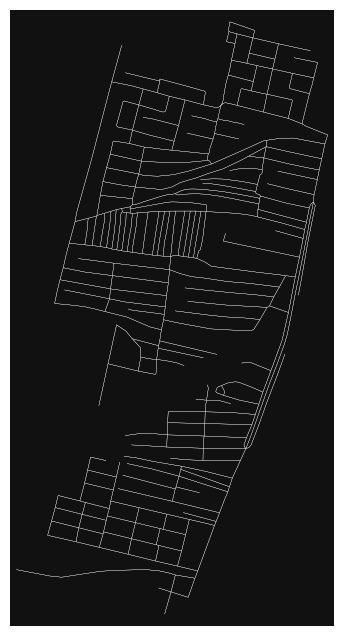

In [39]:
fig, ax = ox.plot_graph(G_clipped_proj_highest, node_size=0, edge_color="w", edge_linewidth=0.2)

In [40]:
## The second highest


Figure for the entire Chennai:

In [41]:
## Path to save the figure:
fig_path = IMAGES_DIR / 'road_density_all_roads_chennai.png'

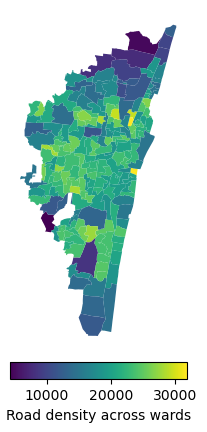

In [42]:
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1, 1)

divider = make_axes_locatable(ax)

cax = divider.append_axes("bottom", size="5%", pad=0.1)

df_merged.plot(
    column="street_density",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={"label": "Road density across wards", "orientation": "horizontal"},
)
ax.set_axis_off()
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()

## References

Boeing, G. (2025). Modeling and Analyzing Urban Networks and Amenities With OSMnx. Geographical Analysis 57, no. 4: 567577. https://doi.org/10.1111/gean.70009.

https://github.com/gboeing/osmnx-examples/tree/f6e821f598ccdb659999d008429cf867c69dcda1/notebooks